# Coroas circulares + precipitação


- `reservatorios_clustering.get_reservatorios_df()` — lê a lista nova
- `extract_precipitation_coroas.carregar_shapefiles_bacias()` — carrega as bacias geradas
- `extract_precipitation_coroas.calcular_geometrias_coroas()` — gera as coroas recortadas pela bacia
- `extract_precipitation_coroas.processar_coroas()` — varre os GRIB2 e monta o DataFrame final

*rodar antes o `gerar_bacias_clustering.ipynb`


In [1]:
from datetime import datetime
from pathlib import Path

from reservatorios_clustering import get_reservatorios_df
from extrair_precip_coroas import (carregar_shapefiles_bacias, calcular_geometrias_coroas, processar_coroas)

# Caminhos (relativos à pasta 'merge teste')
MERGE_DIR = Path("./dados/merge")
SHAPEFILE_DIR = Path("./dados/bacias_clustering")
CSV_RES = Path("./dados/coordenadasUHEs_clustering.csv")
OUTPUT_CSV = Path("./dados/precipitacao_coroas.csv")

N_COROAS = 5
INICIO = datetime(2000, 1, 1)
FIM = datetime(2025, 12, 31)

In [2]:
df_res = get_reservatorios_df(CSV_RES)
print(f"{len(df_res)} reservatórios")
df_res.head()

32 reservatórios


,nome,rio,uf,lat_dam,lon_dam,buffer_deg
0,14 DE JULHO,,,-29.069444,-51.675278,1.0
1,A. VERMELHA,,,-19.868056,-50.342778,1.0
2,B.COQUEIROS,,,-18.721111,-51.004444,1.0
3,BALBINA,,,-1.913611,-59.473889,1.0
4,BATALHA,,,-17.345556,-47.489444,1.0


## 1. Entender as coroas em um reservatório


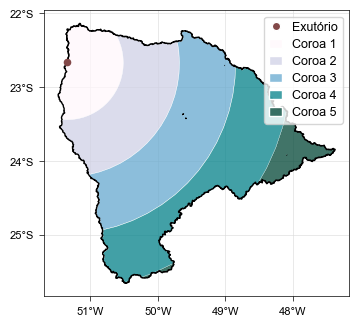

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter


plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stix",
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

cm = 1/2.54

bacias = carregar_shapefiles_bacias(SHAPEFILE_DIR, df_res)
nome = "CAPIVARA"
res = df_res[df_res["nome"] == nome].iloc[0]
geom_bacia = bacias[nome].geometry.union_all()
coroas = calcular_geometrias_coroas(
    geom_bacia, res["lat_dam"], res["lon_dam"], n_coroas=N_COROAS
)



fig, ax = plt.subplots(figsize=(10*cm, 8*cm), layout="constrained")


cmap = colormaps["PuBuGn"]
cores = [(cmap((k - 1) / max(N_COROAS - 1, 1)), 0.75) for k in range(1, N_COROAS + 1)]
for c, cor in zip(coroas, cores):
    if c is not None and not c.is_empty:
        gpd.GeoSeries([c], crs="EPSG:4326").plot(
            ax=ax, color=cor, edgecolor="white", linewidth=0.3
        )

gpd.GeoSeries([geom_bacia], crs="EPSG:4326").boundary.plot(
    ax=ax, color="black", linewidth=1
)
ax.scatter([res["lon_dam"]], [res["lat_dam"]], c="#834949", s=20, zorder=5)

#ax.set_aspect("equal")

# ticks em graus inteiros, sem decimal, com hemisferio (evita a virgula do locale)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda v, _: "0°" if abs(v) < 1e-6 else f"{abs(v):.0f}°{'W' if v < 0 else 'E'}"))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda v, _: "0°" if abs(v) < 1e-6 else f"{abs(v):.0f}°{'S' if v < 0 else 'N'}"))

# legenda dentro do eixo, com entradas reais (exutório primeiro)
handles = [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#834949",
                  markeredgecolor="white", markersize=6, label="Exutório")]
handles += [Patch(facecolor=cor, edgecolor="white", label=f"Coroa {k}")
            for k, cor in enumerate(cores, start=1)]

ax.legend(handles=handles, loc="upper right", frameon=True,
          fontsize=9, handlelength=1.0, labelspacing=0.4)

# Moldura estilo theme_bw: caixa preta fina + grid cinza claro
ax.set_axisbelow(True)
ax.grid(True, color="0.85", linewidth=0.4, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)
ax.tick_params(color="black", width=0.5)


fig.savefig("exemplo_coroas_capivara.png", dpi=300)


## 2. Processar para cada reservatório

Usa os arquivos MERGE GRIB2 no período e extrai a precipitação média de cada coroa.


In [59]:
df = processar_coroas(
    merge_dir=MERGE_DIR,
    shapefile_dir=SHAPEFILE_DIR,
    data_inicio=INICIO,
    data_fim=FIM,
    n_coroas=N_COROAS,
    df_res=df_res,
)
print(df.shape)
df.head()

Carregando shapefiles das bacias...
Bacias carregadas: 32/32

Gerando 5 coroas por reservatório...
  14 DE JULHO: 5/5 coroas com interseção
  A. VERMELHA: 5/5 coroas com interseção
  B.COQUEIROS: 5/5 coroas com interseção
  BALBINA: 5/5 coroas com interseção
  BATALHA: 5/5 coroas com interseção
  CANOAS II: 5/5 coroas com interseção
  CAPIVARA: 5/5 coroas com interseção
  CASTRO ALVES: 5/5 coroas com interseção
  COLIDER: 5/5 coroas com interseção
  D. FRANCISCA: 5/5 coroas com interseção
  DARDANELOS: 5/5 coroas com interseção
  EMBORCAÃÃO: 5/5 coroas com interseção
  ESPORA: 5/5 coroas com interseção
  FOZ CHAPECO: 5/5 coroas com interseção
  G. P. SOUZA: 5/5 coroas com interseção
  GARIBALDI: 5/5 coroas com interseção
  IRAPE: 5/5 coroas com interseção
  ITAPEBI: 5/5 coroas com interseção
  ITÃ: 5/5 coroas com interseção
  JUPIA: 5/5 coroas com interseção
  P. COLOMBIA: 5/5 coroas com interseção
  PICADA: 5/5 coroas com interseção
  PORTO PRIMAVERA: 5/5 coroas com interseção
  RO

Processando MERGE: 100%|██████████| 9497/9497 [18:32:33<00:00,  7.03s/it]   


(9497, 160)


,14 DE JULHO_coroa1,14 DE JULHO_coroa2,14 DE JULHO_coroa3,14 DE JULHO_coroa4,14 DE JULHO_coroa5,A. VERMELHA_coroa1,A. VERMELHA_coroa2,A. VERMELHA_coroa3,A. VERMELHA_coroa4,A. VERMELHA_coroa5,...,BILLINGS_coroa1,BILLINGS_coroa2,BILLINGS_coroa3,BILLINGS_coroa4,BILLINGS_coroa5,PONTE NOVA_coroa1,PONTE NOVA_coroa2,PONTE NOVA_coroa3,PONTE NOVA_coroa4,PONTE NOVA_coroa5
data,,,,,,,,,,,,,,,,,,,,,
2000-01-01,0.464887,2.554066,2.774577,4.949633,19.068804,21.065792,17.995886,15.665335,30.407439,26.961850,...,0.0,0.0,0.0,0.0,0.0,32.386894,21.554423,26.337728,40.364890,27.952275
2000-01-02,0.089385,0.305838,0.458982,4.579006,13.627038,33.205625,33.996666,44.416974,48.085924,55.497690,...,0.0,0.0,0.0,0.0,0.0,30.126784,33.187751,39.616588,37.016570,40.002081
2000-01-03,0.000000,0.000000,0.000000,0.063410,0.124592,36.395155,53.129143,73.740131,86.832471,58.253101,...,0.0,0.0,0.0,0.0,0.0,14.156874,16.932122,24.665530,31.433309,33.898805
2000-01-04,0.000000,0.255508,0.744390,2.393197,2.372889,9.600671,21.842782,43.412780,56.499588,35.293186,...,0.0,0.0,0.0,0.0,0.0,23.020759,26.595335,24.341130,23.402262,24.262873
2000-01-05,0.000000,0.080011,0.827866,3.232963,4.004411,8.991152,24.492696,32.875428,27.501347,16.048023,...,0.0,0.0,0.0,0.0,0.0,16.400919,18.511592,16.880537,13.716251,14.400175


## 3. Salvar e resumir

In [60]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, float_format="%.2f")

print(f"Dimensões: {df.shape[0]} dias × {df.shape[1]} colunas")

n_res = len(set(c.rsplit("_coroa", 1)[0] for c in df.columns))
pct_nan = 100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1])

print(f"Reservatórios: {n_res} | Coroas por reservatório: {N_COROAS}")
print(f"NaN total: {pct_nan:.1f}%")

Dimensões: 9497 dias × 160 colunas
Reservatórios: 32 | Coroas por reservatório: 5
NaN total: 0.0%


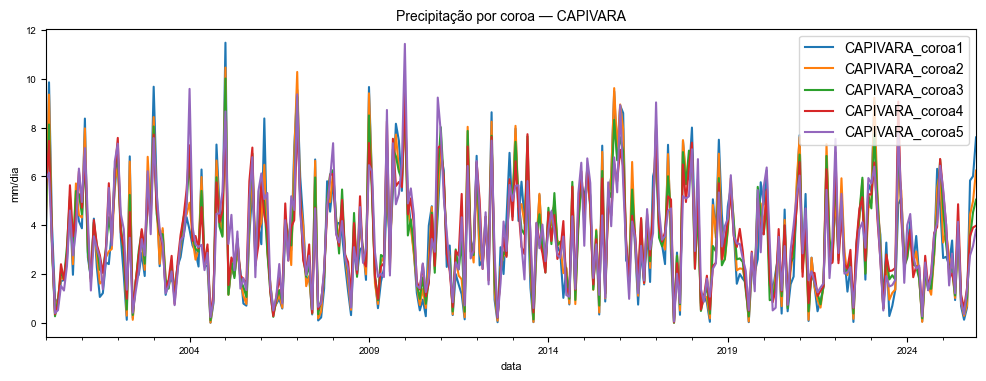

In [61]:
# Exemplo: série das 5 coroas de um reservatório (média mensal)
cols = [c for c in df.columns if c.startswith(nome + "_coroa")]
df[cols].resample("MS").mean().plot(figsize=(12, 4), title=f"Precipitação por coroa — {nome}")
plt.ylabel("mm/dia")
plt.show()